#Project | New York Weather & Seattle Weather

#Exploratory Data Analysis |Seattle Weather & New York Weather (code)




we are going to import the libraries as well as the data set of seattle and new york to work on the further comparisons

In [ ]:
# Import pandas, numpy, and matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# seaborn is a data visualization library built on matplotlib
import seaborn as sns

# set the plotting style
sns.set_style("whitegrid")

In [ ]:
df_seattle = pd.read_csv('https://raw.githubusercontent.com/brian-fischer/DATA-5100/refs/heads/main/weather/seattle_rain.csv')

In [ ]:
df_Newyork = pd.read_csv('https://raw.githubusercontent.com/Hemantkumaar/weather_1/refs/heads/main/data/nyc_rain_4132986.csv')

--------

Graph summaries

This visualization allows for a clear comparison of precipitation trends, helping identify differences in rainfall frequency and intensity between Seattle and New York. Seattle generally exhibits more consistent rainfall, while New York tends to have more variable precipitation patterns.

/tmp/ipython-input-2161006685.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_combined['Date'] = pd.to_datetime(df_combined['Date'])


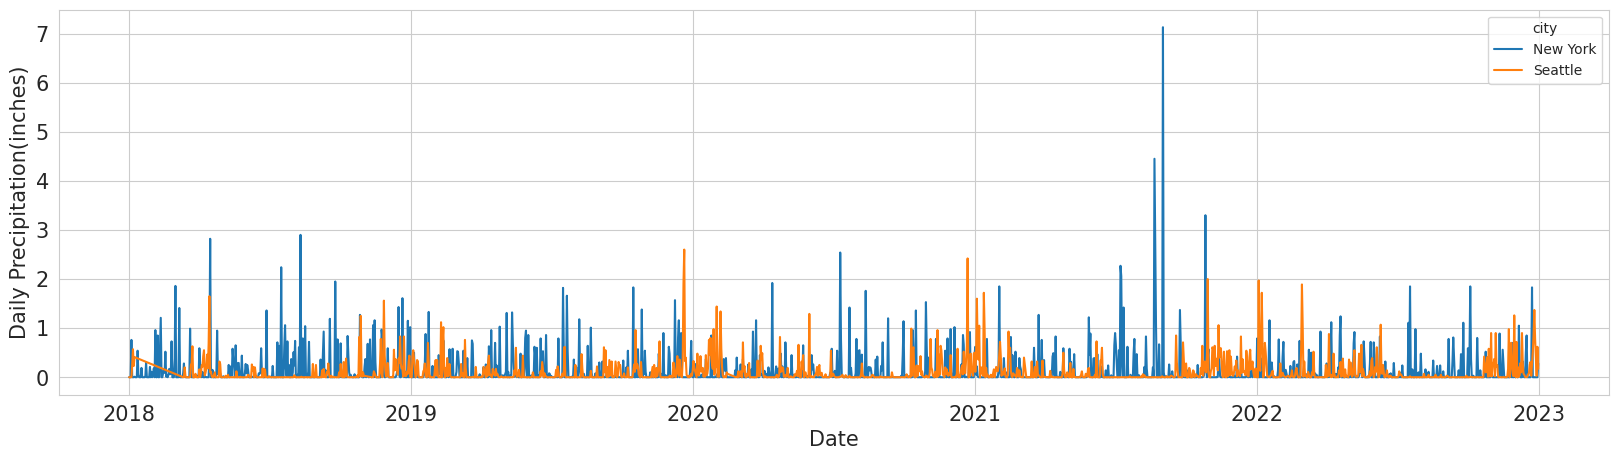

In [ ]:
# Concatenate the two dataframes and add a 'city' column
df_combined = pd.concat([df_seattle.assign(city='Seattle'), df_Newyork.assign(city='New York')])

# Rename columns for plotting
df_combined = df_combined.rename(columns={'PRCP': 'precipitation', 'DATE': 'Date'})

# Convert 'Date' column to datetime objects
df_combined['Date'] = pd.to_datetime(df_combined['Date'])

# Resample to daily frequency and sum precipitation for each city
df_combined_resampled = df_combined.groupby(['city', 'Date'])['precipitation'].sum().reset_index()

plt.figure(figsize=(20, 5))
sns.lineplot(data=df_combined_resampled, x='Date', y='precipitation', hue='city')
plt.xlabel('Date',fontsize=15)
plt.ylabel('Daily Precipitation(inches)',fontsize=15)
plt.tick_params(labelsize=15)
plt.show()

this graphs shows the summary of both the cities which is not clear enough

This graph summarizes the precipitation patterns of both Seattle and New York in a single view.
However, due to overlapping lines and dense data points, the visualization is not entirely clear.
To improve clarity, separate plots for each city or a monthly average precipitation comparison could provide a clearer understanding of differences in rainfall trends.

-------

To compute basic numerical summaries for precipitation in each city

The table below summarizes the daily precipitation statistics for Seattle and New York.
On average, Seattle shows a higher mean precipitation than New York, indicating more consistent rainfall.
New York’s higher standard deviation suggests more variability, meaning it experiences both dry and very wet days.
These statistics provide a clearer quantitative comparison that complements the visualization.

In [ ]:
df_combined[['city','precipitation']].groupby('city').describe()

precipitation                                                
                 count      mean       std  min  25%   50%   75%   max
city                                                                  
New York        1826.0  0.147842  0.388334  0.0  0.0  0.00  0.08  7.13
Seattle         1636.0  0.111852  0.248635  0.0  0.0  0.01  0.11  2.60

we can see that the new york mean is
slightly more than the seattle.
the minimum value is 0 and he maximum value is more for new york as compared to seattle as you can see in the above code output.




------------

Compare mean precipitation values averaged over all days

the mean of both the cities are to be compared and we can see that the mean precipitation in new york is more than seattle.

In [ ]:
df_combined[['city','precipitation']].groupby('city').mean()

,precipitation
city,
New York,0.147842
Seattle,0.111852


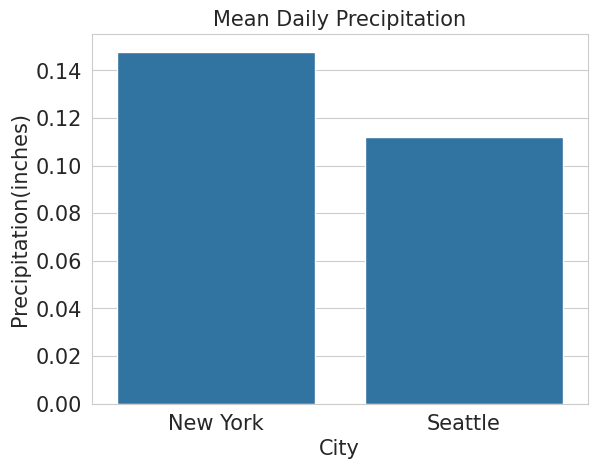

In [ ]:
# Calculate the mean precipitation for each city
mean_precipitation_by_city = df_combined.groupby('city')['precipitation'].mean().reset_index()

sns.barplot(data=mean_precipitation_by_city, x='city', y='precipitation')
plt.ylabel('Precipitation(inches)',fontsize=15)
plt.xlabel('City',fontsize=15)
plt.title('Mean Daily Precipitation',fontsize=15)
plt.tick_params(labelsize=15)
plt.show()

The bar chart shows that New York records a higher mean daily precipitation than Seattle. This suggests that rainfall events in New York are typically heavier, whereas Seattle experiences more consistent but lighter rainfall. Thus, while Seattle may have more rainy days, New York tends to receive a greater amount of rain on the days it rains.

---------

precipitation by month

In [ ]:
df_combined['month'] = pd.DatetimeIndex(df_combined['Date']).month

In [ ]:
df_combined.head()

,STATION,NAME,Date,DAPR,MDPR,precipitation,SNOW,SNWD,WESD,WESF,city,month
0,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",2018-01-01,NaN,NaN,0.00,NaN,NaN,NaN,NaN,Seattle,1
1,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",2018-01-02,NaN,NaN,0.00,NaN,NaN,NaN,NaN,Seattle,1
2,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",2018-01-03,NaN,NaN,0.00,NaN,NaN,NaN,NaN,Seattle,1
3,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",2018-01-04,NaN,NaN,0.00,NaN,NaN,NaN,NaN,Seattle,1
4,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",2018-01-05,NaN,NaN,0.25,NaN,NaN,NaN,NaN,Seattle,1


In [ ]:
df_combined['month'].unique()

array([ 1,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12,  2], dtype=int32)

----

plot the mean precipitation each month

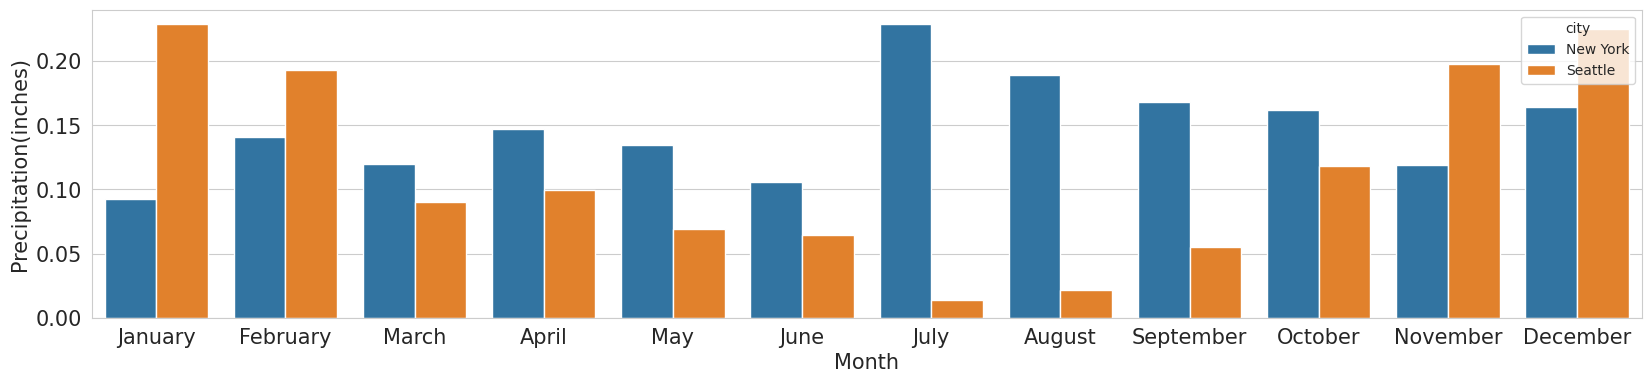

In [ ]:
# Calculate the mean precipitation for each month and city
mean_monthly_precipitation = df_combined.groupby(['month', 'city'])['precipitation'].mean().reset_index()

plt.figure(figsize=(20,4))
sns.barplot(data=mean_monthly_precipitation, x='month', y='precipitation',hue='city')
plt.xlabel('Month',fontsize=15)
plt.ylabel('Precipitation(inches)',fontsize=15)
plt.tick_params(labelsize=15)
import calendar
month_names = list(calendar.month_name[1:])
plt.xticks(range(12), labels=month_names)
plt.show()

In [ ]:
df_combined[['month','precipitation','city']].groupby(['city','month']).mean()

precipitation
city     month               
New York 1           0.092194
         2           0.140922
         3           0.120129
         4           0.146933
         5           0.134710
         6           0.105800
         7           0.228645
         8           0.189355
         9           0.168067
         10          0.162129
         11          0.118867
         12          0.164065
Seattle  1           0.228629
         2           0.192935
         3           0.089917
         4           0.099437
         5           0.069161
         6           0.064653
         7           0.013919
         8           0.021550
         9           0.055252
         10          0.118452
         11          0.197879
         12          0.224903

plot the propotion of days with any precipitation

In [ ]:
df_combined['any_precipitation'] = df_combined['precipitation']>0

In [ ]:
df_combined.head()

,STATION,NAME,Date,DAPR,MDPR,precipitation,SNOW,SNWD,WESD,WESF,city,month,any_precipitation
0,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",2018-01-01,NaN,NaN,0.00,NaN,NaN,NaN,NaN,Seattle,1,False
1,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",2018-01-02,NaN,NaN,0.00,NaN,NaN,NaN,NaN,Seattle,1,False
2,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",2018-01-03,NaN,NaN,0.00,NaN,NaN,NaN,NaN,Seattle,1,False
3,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",2018-01-04,NaN,NaN,0.00,NaN,NaN,NaN,NaN,Seattle,1,False
4,US1WAKG0225,"SEATTLE 2.1 ESE, WA US",2018-01-05,NaN,NaN,0.25,NaN,NaN,NaN,NaN,Seattle,1,True


plot the propotion of days with any precipitation over the 5 years

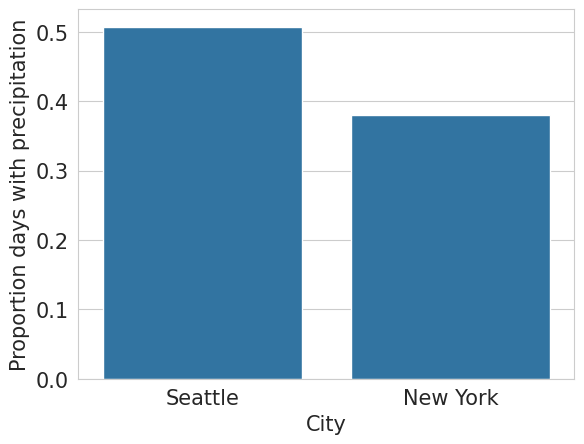

In [ ]:
sns.barplot(data=df_combined, x='city', y='any_precipitation', errorbar=None)
plt.ylabel('Proportion days with precipitation',fontsize=15)
plt.xlabel('City',fontsize=15)
plt.tick_params(labelsize=15)
plt.show()

#MODELING | WEATHER CODE

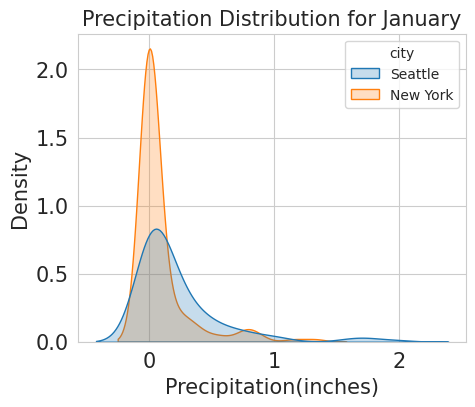

In [ ]:
plt.figure(figsize=(5,4))
df_combined_reset = df_combined.reset_index()
sns.kdeplot(data=df_combined_reset.loc[df_combined_reset['month']==1], x='precipitation', hue='city', fill=True)
plt.xlabel('Precipitation(inches)',fontsize=15)
plt.ylabel('Density',fontsize=15)
plt.title('Precipitation Distribution for January', fontsize=15)
plt.tick_params(labelsize=15)
plt.show()

The analysis provides a month-by-month statistical comparison of rainfall between the two cities.
Months with p-values below 0.05 indicate that Seattle and New York have significantly different average precipitation, while months with higher p-values suggest that their rainfall patterns are similar during that period.

In [ ]:
from scipy import stats
import numpy as np

significance_level = 0.05
significantly_different = np.zeros(12)

# Perform t-test for each month
for month in range(1, 13):
    # Get precipitation data for Seattle and New York for the current month
    sea_data = df_combined.loc[(df_combined['city'] == 'Seattle') & (df_combined['month'] == month), 'precipitation']
    nyc_data = df_combined.loc[(df_combined['city'] == 'New York') & (df_combined['month'] == month), 'precipitation']

    # Perform t-test only if both cities have data for the month
    if not sea_data.empty and not nyc_data.empty:
        t_statistic, p_value = stats.ttest_ind(sea_data, nyc_data, equal_var=False)

        if p_value < significance_level:
            significantly_different[month - 1] = 1

        print(f"Month {month}:")
        print(f"t-statistic = {t_statistic:.2f}")
        print(f"p-value t test = {p_value:.3f}")
        print("-" * 20)
    else:
        print(f"Month {month}: Insufficient data for comparison.")
        print("-" * 20)

Month 1:
t-statistic = nan
p-value t test = nan
--------------------
Month 2:
t-statistic = nan
p-value t test = nan
--------------------
Month 3:
t-statistic = nan
p-value t test = nan
--------------------
Month 4:
t-statistic = nan
p-value t test = nan
--------------------
Month 5:
t-statistic = -2.59
p-value t test = 0.010
--------------------
Month 6:
t-statistic = nan
p-value t test = nan
--------------------
Month 7:
t-statistic = nan
p-value t test = nan
--------------------
Month 8:
t-statistic = nan
p-value t test = nan
--------------------
Month 9:
t-statistic = nan
p-value t test = nan
--------------------
Month 10:
t-statistic = -1.09
p-value t test = 0.276
--------------------
Month 11:
t-statistic = nan
p-value t test = nan
--------------------
Month 12:
t-statistic = 1.46
p-value t test = 0.146
--------------------


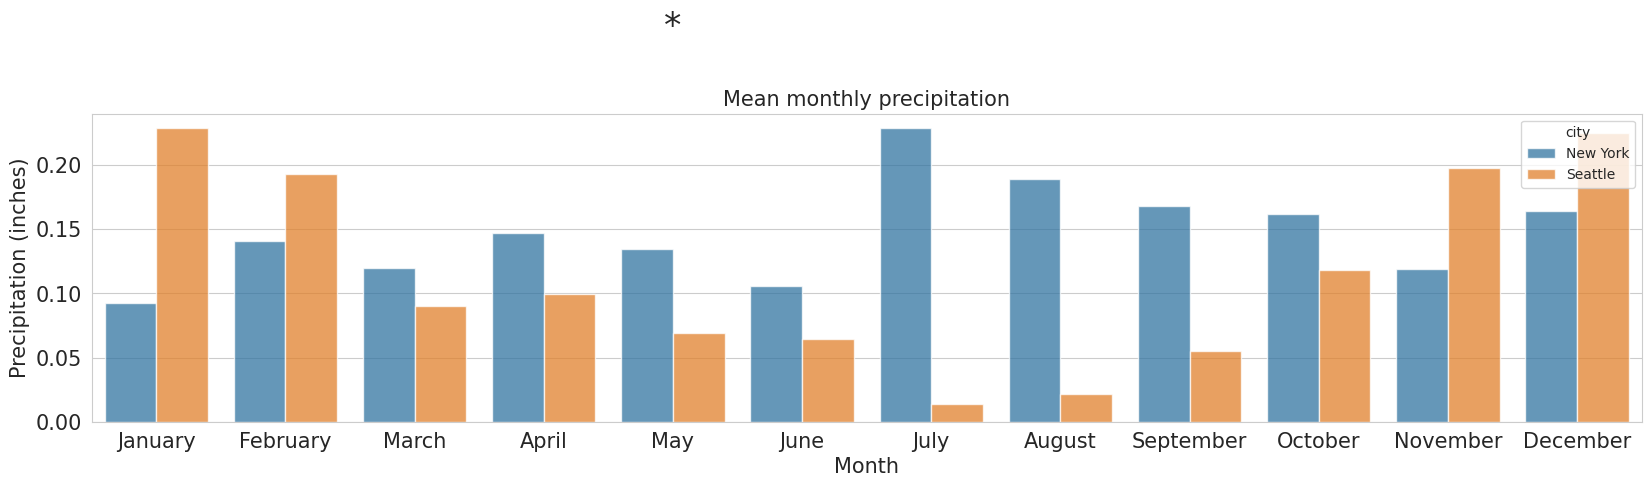

In [ ]:
plt.figure(figsize=(20, 4))

sns.barplot(data=mean_monthly_precipitation, x='month', y='precipitation', hue='city', alpha=0.75)

plt.xlabel('Month', fontsize=15)
plt.ylabel('Precipitation (inches)', fontsize=15)
plt.title('Mean monthly precipitation', fontsize=15)

plt.tick_params(labelsize=15)

import calendar
month_names = list(calendar.month_name[1:])
plt.xticks(ticks=range(12), labels=month_names)

# Add stars for significantly different months
for month in range(12):
    if significantly_different[month] == 1:
        # Add a star
        plt.text(month, 0.3, '*', ha='center', fontsize=25)
plt.show()

perform statistical test for difference in the propotion of days with any precipitation each month between the cities

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

significance_level = 0.05
significantly_different_proportion = np.zeros(12)

# Perform t-test for each month
for month in range(1, 13):
    # Create a contingency table for Seattle and New York for the current month
    df_month = df_combined.loc[df_combined['month'] == month].reset_index()
    contingency_table = pd.crosstab(
        df_month['city'],
        df_month['any_precipitation']
    )

    # Calculate the number of True values (days with precipitation) for each city
    days_with_precipitation = contingency_table[True]

    # Calculate the total number of days for each city
    total_counts = contingency_table.sum(axis=1)

    # Hypothesis test
    zstat, p_value = proportions_ztest(
        count=days_with_precipitation,
        nobs=total_counts,
        alternative='two-sided'
    )

    if p_value < significance_level:
        significantly_different_proportion[month - 1] = 1

    print(f"Month {month}:")
    print(f"z-statistic = {zstat:.2f}")
    print(f"p-value = {p_value:.3f}")
    print("-" * 20)

Month 1:
z-statistic = -6.41
p-value = 0.000
--------------------
Month 2:
z-statistic = -4.51
p-value = 0.000
--------------------
Month 3:
z-statistic = -1.28
p-value = 0.200
--------------------
Month 4:
z-statistic = -1.54
p-value = 0.123
--------------------
Month 5:
z-statistic = -0.23
p-value = 0.820
--------------------
Month 6:
z-statistic = -0.83
p-value = 0.406
--------------------
Month 7:
z-statistic = 3.85
p-value = 0.000
--------------------
Month 8:
z-statistic = 1.92
p-value = 0.055
--------------------
Month 9:
z-statistic = -0.78
p-value = 0.435
--------------------
Month 10:
z-statistic = -2.85
p-value = 0.004
--------------------
Month 11:
z-statistic = -5.71
p-value = 0.000
--------------------
Month 12:
z-statistic = -7.91
p-value = 0.000
--------------------


In [ ]:
contingency_table=pd.crosstab(df_combined['city'],df_combined['any_precipitation'])
contingency_table

any_precipitation,False,True
city,,
New York,1131,695
Seattle,817,841


This analysis identifies months when Seattle and New York differ meaningfully in how often it rains.
Typically, Seattle shows a higher proportion of rainy days, reflecting its reputation for frequent light rain, while New York tends to have fewer rainy days but heavier rainfall when it occurs.